In [14]:
import os
import sys
import glob
import yaml
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Magia de Rutas
project_root = os.path.abspath('../../')
if project_root not in sys.path:
    sys.path.append(project_root)

# 2. Cargar Configuración (Ajusta la ruta al YAML que estés probando)
CONFIG_PATH = '../../configs/experiments/feat_task_k4_diag_pca90.yaml'

with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

# 3. Variables Dinámicas
n_states = cfg['pipeline']['hmm']['k_states']
exp_name = cfg['experiment']['name']
fs = 250 # Frecuencia de muestreo (ajustar si es diferente)

exp_dir = f"../../outputs/processed/experiments/feature_hmm/task/{exp_name}/"
features_dir = "../../data/interim/features/task/"
preproc_dir = "../../data/interim/preprocessed/task/"

print(f"Cargando experimento: {exp_name} (K={n_states})")

# Cargar Viterbi Paths
viterbi_paths = np.load(os.path.join(exp_dir, f'viterbi_paths_k{n_states}.npy'))

# Cargar archivos de longitud para separar sujetos
all_lengths = np.load(os.path.join(exp_dir, 'all_lengths.npy'))
subject_files = sorted(glob.glob(os.path.join(features_dir, '*_lengths.npy')))

print(f"Datos cargados: {len(viterbi_paths)} ventanas para {len(subject_files)} sesiones.")

Cargando experimento: feat_task_k4_diag_pca90 (K=4)
Datos cargados: 143899 ventanas para 118 sesiones.


In [9]:
all_subject_data = []
current_pos = 0

for i, f_path in enumerate(subject_files):
    # 1. Parsear metadatos del archivo
    fname = os.path.basename(f_path)
    subject_id = fname.split('_')[0]
    group = 'ADULT' if 'ADULTS' in fname.upper() else 'ADOLESCENT'
    condition = 'NO-GO' if 'NOGO' in fname.upper() else 'GO'
    
    # 2. Extraer el segmento de Viterbi para este sujeto
    subj_lengths = np.load(f_path)
    total_subj_samples = np.sum(subj_lengths)
    subj_viterbi = viterbi_paths[current_pos : current_pos + total_subj_samples]
    current_pos += total_subj_samples
    
    # 3. Diccionario de resultados para el sujeto
    res = {'Subject': subject_id, 'Group': group, 'Condition': condition}
    
    # 4. Cálculo de métricas por estado
    for s in range(n_states):
        state_mask = (subj_viterbi == s)
        
        # FO: Fractional Occupancy (%)
        res[f'FO_State_{s}'] = (np.sum(state_mask) / len(subj_viterbi)) * 100
        
        # Dwell Time (ms)
        # Identificar cambios de estado para medir duraciones
        diffs = np.diff(subj_viterbi == s, prepend=0, append=0)
        starts = np.where(diffs == 1)[0]
        stops = np.where(diffs == -1)[0]
        durations = (stops - starts) * (1000 / fs) # Convertir a ms
        res[f'Dwell_State_{s}'] = np.mean(durations) if len(durations) > 0 else 0
        
    # 5. Transition Rate (Hz)
    n_transitions = np.sum(np.diff(subj_viterbi) != 0)
    res['Transition_Rate_Hz'] = n_transitions / (len(subj_viterbi) / fs)
    
    all_subject_data.append(res)

df_subjects = pd.DataFrame(all_subject_data)
print("DataFrame clínico generado exitosamente.")

DataFrame clínico generado exitosamente.


In [10]:
# ============================================================
# DISTRIBUCIÓN GLOBAL DE ESTADOS (FRACTIONAL OCCUPANCY TOTAL)
# ============================================================
import numpy as np

# Total de ventanas procesadas por el modelo
total_windows = len(viterbi_paths)

# FIX: El título ahora lee dinámicamente la variable n_states
print(f"=== Distribución Global de Microestados (K={n_states}) ===")
print(f"Total de ventanas analizadas: {total_windows:,}\n")

for s in range(n_states):
    # Contar cuántas ventanas en toda la base de datos pertenecen al estado 's'
    state_count = np.sum(viterbi_paths == s)
    
    # Calcular el porcentaje global
    global_percentage = (state_count / total_windows) * 100
    
    # Imprimir con el formato exacto que solicitaste
    print(f"State {s}: {global_percentage:.2f}%")

=== Distribución Global de Microestados (K=4) ===
Total de ventanas analizadas: 143,899

State 0: 50.74%
State 1: 4.76%
State 2: 18.17%
State 3: 26.33%


In [15]:
import os
import glob
import numpy as np
import pandas as pd

start_idx = 0
all_stats = []
fs = 250 # Frecuencia de muestreo para calcular milisegundos y Hz

ADULTS = [
    'AAELSC', 'AAGFSC', 'EDGSSIN', 'FIJRBSIN',
    'GSASC', 'IJALSC', 'JAGSSC', 'LHACSIN',
    'MAEGLSC', 'MAHLSC', 'MFGSIN', 'MGOKSC',
    'RAMPSIN', 'SDBGSIN', 'VMRSIN', 'AVLLSC',
    'BMPSC', 'CGMSIN', 'CJGSIN', 'CPGSC',
    'CPMHSIN', 'GGMSIN', 'IABWSC', 'JAUSIN',
    'JGCSC', 'MGVGSC', 'RKACSC', 'SEOOSIN',
    'TTOSC', 'VBPSIN'
]

def infer_group(subject):
    for adult in ADULTS:
        if subject.startswith(adult):
            return "Adulto"
    return "Adolescente"

# Nos aseguramos de usar la ruta de preprocesados que definiste arriba
fif_files = sorted(glob.glob(os.path.join(preproc_dir, '*.fif')))

print("Sincronizando el HMM con los metadatos clínicos...")
for fif_path in fif_files:
    filename = os.path.basename(fif_path)
    
    # 1. Quitar la basura del final para quedarnos con algo como "AAELSCGO" o "AAELSCNOGO"
    clean_name = filename.replace('_sin_contexto_epo.fif', '').replace('_epo.fif', '')
    clean_name_upper = clean_name.upper()
    
    # 2. Separar el Sujeto Real de la Condición
    if clean_name_upper.endswith("NOGO"):
        condition_name = "NO-GO"
        subject_id_real = clean_name[:-4]
    elif clean_name_upper.endswith("NG"):
        condition_name = "NO-GO"
        subject_id_real = clean_name[:-2]
    elif clean_name_upper.endswith("GO"):
        condition_name = "GO"
        subject_id_real = clean_name[:-2]
    else:
        condition_name = "Desconocida"
        subject_id_real = clean_name
        
    group = infer_group(subject_id_real)
    
    # 3. Leer las longitudes
    file_id_for_npy = filename.replace('_epo.fif', '') 
    subj_lengths = np.load(os.path.join(features_dir, f"{file_id_for_npy}_lengths.npy"))
    
    # 4. Extraer MÉTRICAS CLÍNICAS por cada época
    for ep_idx, ep_len in enumerate(subj_lengths):
        ep_path = viterbi_paths[start_idx : start_idx + ep_len]
        
        fo_dict = {
            'Subject': subject_id_real, 
            'Group': group,
            'Condition': condition_name,
            'Epoch_ID': ep_idx
        }
        
        # --- CÁLCULOS DINÁMICOS DEPENDIENTES DE K ---
        for s in range(n_states):
            # A. Fractional Occupancy (%)
            fo_dict[f'FO_State_{s}'] = np.mean(ep_path == s) * 100 
            
            # B. Dwell Time (Milisegundos)
            diffs = np.diff(ep_path == s, prepend=0, append=0)
            starts = np.where(diffs == 1)[0]
            stops = np.where(diffs == -1)[0]
            durations = (stops - starts) * (1000 / fs) # Convertir frames a ms
            fo_dict[f'Dwell_State_{s}'] = np.mean(durations) if len(durations) > 0 else 0
            
        # C. Transition Rate (Hz) -> Independiente de K, evalúa saltos totales
        n_transitions = np.sum(np.diff(ep_path) != 0)
        fo_dict['Transition_Rate_Hz'] = n_transitions / (ep_len / fs)
        
        all_stats.append(fo_dict)
        start_idx += ep_len

# Agrupar por sujeto promediando todas sus épocas
df_epochs = pd.DataFrame(all_stats)
df_subjects = df_epochs.groupby(['Subject', 'Group', 'Condition']).mean(numeric_only=True).reset_index()

print("¡Sincronización completa!")
print("\nSujetos por grupo:")
print(df_subjects.groupby('Group')['Subject'].nunique())
print("\nEnsayos por condición:")
print(df_subjects['Condition'].value_counts())

Sincronizando el HMM con los metadatos clínicos...
¡Sincronización completa!

Sujetos por grupo:
Group
Adolescente    30
Adulto         30
Name: Subject, dtype: int64

Ensayos por condición:
Condition
GO       59
NO-GO    59
Name: count, dtype: int64


c:\Users\pokem\miniconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:.3'` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\pokem\miniconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:.3'` for the same effect.

  func(*plot_args, **plot_kwargs)


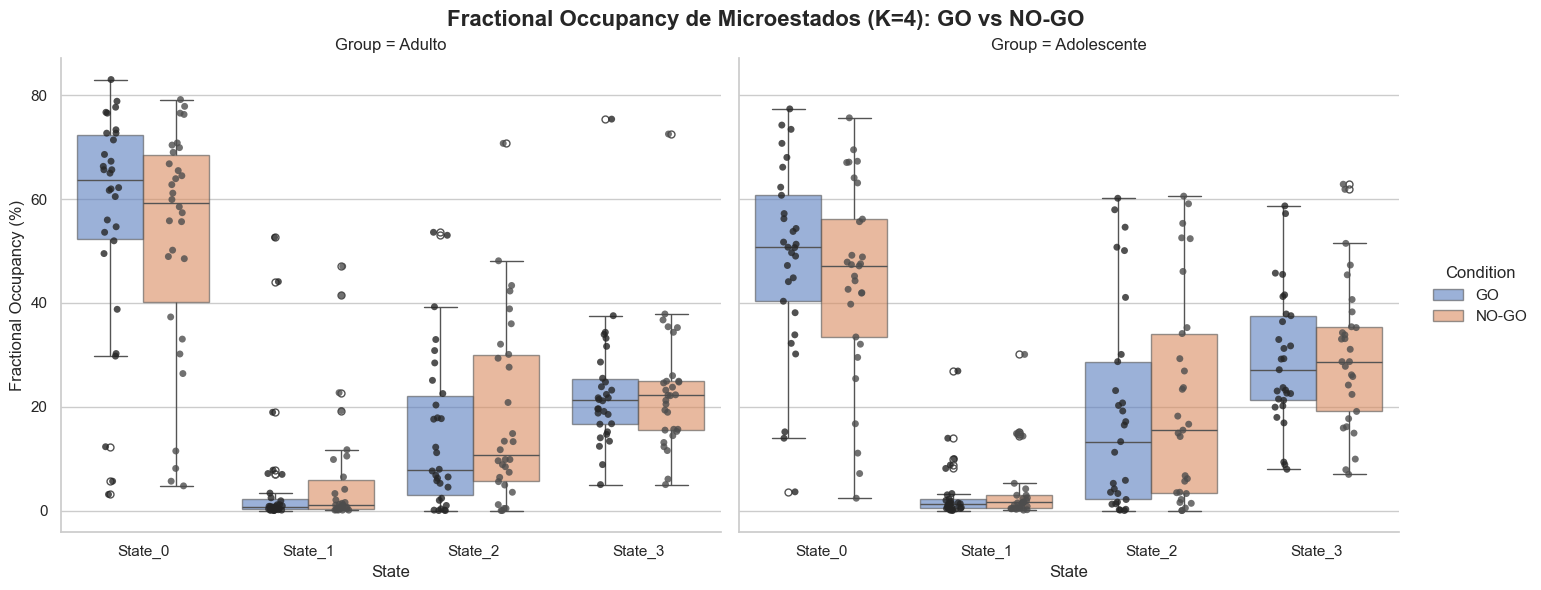

In [16]:
# Configurar estilo de Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Convertir el DataFrame a formato "largo" (Tidy) para que Seaborn lo pueda graficar fácilmente
df_melted = df_subjects.melt(
    id_vars=['Subject', 'Group', 'Condition'], 
    value_vars=[f'FO_State_{s}' for s in range(n_states)],
    var_name='State', 
    value_name='Fractional Occupancy (%)'
)

# Limpiar los nombres de los estados para la gráfica
df_melted['State'] = df_melted['State'].str.replace('FO_', '')

# GRAFICAR: GO vs NO-GO separando por Estado
g = sns.catplot(
    data=df_melted, 
    x='State', 
    y='Fractional Occupancy (%)', 
    hue='Condition', 
    col='Group', # Crea una columna para Adultos y otra para Adolescentes
    kind='box', 
    height=6, 
    aspect=1.2,
    boxprops={'alpha': 0.6}
)

# Añadir los puntos individuales para ver la dispersión real de tu muestra
g.map_dataframe(sns.stripplot, x='State', y='Fractional Occupancy (%)', hue='Condition', dodge=True, alpha=0.8, color=".3")

g.fig.subplots_adjust(top=0.9)
# FIX: Título dinámico para saber qué versión de K estamos viendo
g.fig.suptitle(f"Fractional Occupancy de Microestados (K={n_states}): GO vs NO-GO", fontsize=16, fontweight='bold')
plt.show()

In [18]:
# ============================================================
# MÉTRICAS GLOBALES: GO vs NO-GO (FO y Lifetimes/Dwell Times)
# ============================================================

# Título dinámico para saber en qué modelo estamos
print(f"=== REPORTE POR CONDICIÓN (Modelo K={n_states}) ===\n")

# Asegurarnos de que las condiciones existan en el dataframe
condiciones = ['GO', 'NO-GO']

for cond in condiciones:
    print(f"=== Condición: {cond} ===")
    
    # Filtrar los datos solo para la condición actual
    df_cond = df_subjects[df_subjects['Condition'] == cond]
    
    print("Fractional Occupancy (FO):")
    for s in range(n_states):
        # Extraer el promedio de FO para el estado 's' en esta condición
        mean_fo = df_cond[f'FO_State_{s}'].mean()
        print(f"State {s} → {mean_fo:.2f}%")
        
    print("\nDwell Times / Lifetimes:")
    for s in range(n_states):
        # Extraer el promedio de Dwell Time para el estado 's' en esta condición
        mean_dwell = df_cond[f'Dwell_State_{s}'].mean()
        print(f"State {s} → {mean_dwell:.2f} ms")
        
    print("-" * 30)

=== REPORTE POR CONDICIÓN (Modelo K=4) ===

=== Condición: GO ===
Fractional Occupancy (FO):
State 0 → 53.13%
State 1 → 4.20%
State 2 → 16.65%
State 3 → 26.01%

Dwell Times / Lifetimes:
State 0 → 18.79 ms
State 1 → 3.12 ms
State 2 → 11.75 ms
State 3 → 10.12 ms
------------------------------
=== Condición: NO-GO ===
Fractional Occupancy (FO):
State 0 → 48.36%
State 1 → 5.32%
State 2 → 19.68%
State 3 → 26.64%

Dwell Times / Lifetimes:
State 0 → 16.92 ms
State 1 → 3.90 ms
State 2 → 12.61 ms
State 3 → 10.45 ms
------------------------------


In [19]:
# ============================================================
# SINCRONIZACIÓN Y EXTRACCIÓN DE LA TRINIDAD CLÍNICA
# ============================================================
import os
import glob
import numpy as np
import pandas as pd

# --- CONFIGURACIÓN ---
start_idx = 0
all_stats = []

# IMPORTANTE: Este valor debe coincidir exactamente con el 'step_size_ms' 
# de tu archivo configs/features/task_mega_vector.yaml
WINDOW_STEP_MS = 100 

ADULTS = [
    'AAELSC', 'AAGFSC', 'EDGSSIN', 'FIJRBSIN',
    'GSASC', 'IJALSC', 'JAGSSC', 'LHACSIN',
    'MAEGLSC', 'MAHLSC', 'MFGSIN', 'MGOKSC',
    'RAMPSIN', 'SDBGSIN', 'VMRSIN', 'AVLLSC',
    'BMPSC', 'CGMSIN', 'CJGSIN', 'CPGSC',
    'CPMHSIN', 'GGMSIN', 'IABWSC', 'JAUSIN',
    'JGCSC', 'MGVGSC', 'RKACSC', 'SEOOSIN',
    'TTOSC', 'VBPSIN'
]

def infer_group(subject):
    for adult in ADULTS:
        if subject.startswith(adult):
            return "Adulto"
    return "Adolescente"

def get_mean_dwell_time(path, state, step_ms):
    """Calcula la duración promedio (en ms) de las visitas a un estado específico."""
    is_s = (path == state)
    if not np.any(is_s): 
        return 0.0
    # Buscar bordes donde empieza y termina la racha del estado
    diffs = np.diff(np.concatenate(([0], is_s.view(np.int8), [0])))
    starts = np.where(diffs == 1)[0]
    ends = np.where(diffs == -1)[0]
    durations = ends - starts
    return np.mean(durations) * step_ms

# Aseguramos cargar las longitudes y archivos correctos
fif_files = sorted(glob.glob(os.path.join(preproc_dir, '*.fif')))

print(f"Extrayendo FO, Dwell Time y Transiciones (Ventana de {WINDOW_STEP_MS}ms)...")
for fif_path in fif_files:
    filename = os.path.basename(fif_path)
    clean_name = filename.replace('_sin_contexto_epo.fif', '').replace('_epo.fif', '')
    clean_name_upper = clean_name.upper()
    
    # LÓGICA DE CONDICIÓN (El Atrapa-todo)
    if any(x in clean_name_upper for x in ["NOGO", "NO-GO", "NO_GO", "NOG", "NG"]):
        condition_name = "NO-GO"
        subject_id_real = clean_name[:-4] if clean_name_upper.endswith("NOGO") else clean_name[:-2]
    elif "GO" in clean_name_upper:
        condition_name = "GO"
        subject_id_real = clean_name[:-2]
    else:
        condition_name = "Desconocida"
        subject_id_real = clean_name
        
    group = infer_group(subject_id_real)
    file_id_for_npy = filename.replace('_epo.fif', '') 
    
    # Cargar archivo de longitudes correspondiente al sujeto
    subj_lengths = np.load(os.path.join(features_dir, f"{file_id_for_npy}_lengths.npy"))
    
    # EXTRAER MÉTRICAS POR ÉPOCA
    for ep_idx, ep_len in enumerate(subj_lengths):
        ep_path = viterbi_paths[start_idx : start_idx + ep_len]
        epoch_duration_sec = ep_len * (WINDOW_STEP_MS / 1000.0)
        
        metrics_dict = {
            'Subject': subject_id_real,
            'Group': group,
            'Condition': condition_name,
            'Epoch_ID': ep_idx,
            # Tasa de transiciones (Cuántas veces cambió de estado por segundo)
            'Transition_Rate_Hz': np.sum(np.diff(ep_path) != 0) / epoch_duration_sec if epoch_duration_sec > 0 else 0
        }
        
        # FO y Dwell Time dinámicos por cada estado (Soporta cualquier K)
        for s in range(n_states):
            metrics_dict[f'FO_State_{s}'] = np.mean(ep_path == s) * 100 
            metrics_dict[f'Dwell_State_{s}'] = get_mean_dwell_time(ep_path, s, WINDOW_STEP_MS)
            
        all_stats.append(metrics_dict)
        start_idx += ep_len

# Consolidar y promediar por sujeto
df_epochs = pd.DataFrame(all_stats)
df_subjects = df_epochs.groupby(['Subject', 'Group', 'Condition']).mean(numeric_only=True).reset_index()

print(f"¡Extracción de la Trinidad Clínica completada para {n_states} estados!")
display(df_subjects.head())

Extrayendo FO, Dwell Time y Transiciones (Ventana de 100ms)...
¡Extracción de la Trinidad Clínica completada para 4 estados!


,Subject,Group,Condition,Epoch_ID,Transition_Rate_Hz,FO_State_0,Dwell_State_0,FO_State_1,Dwell_State_1,FO_State_2,Dwell_State_2,FO_State_3,Dwell_State_3
0,AAELSC,Adulto,GO,9.5,2.254098,73.360656,645.122655,0.409836,12.500000,2.377049,85.000000,23.852459,234.031746
1,AAELSC,Adulto,NO-GO,9.5,2.631148,69.016393,542.605700,0.655738,35.000000,5.573770,177.916667,24.754098,209.465007
2,AAGFSC,Adulto,GO,9.5,2.377049,65.655738,558.301407,0.000000,0.000000,17.704918,392.083333,16.639344,173.041667
3,AAGFSC,Adulto,NO-GO,9.5,2.606557,50.163934,430.128247,1.557377,60.833333,29.344262,503.250000,18.934426,205.533730
4,ACBSIN,Adolescente,NO-GO,9.5,3.106557,51.762295,365.847312,1.475410,54.196429,13.360656,357.410714,33.401639,245.782964


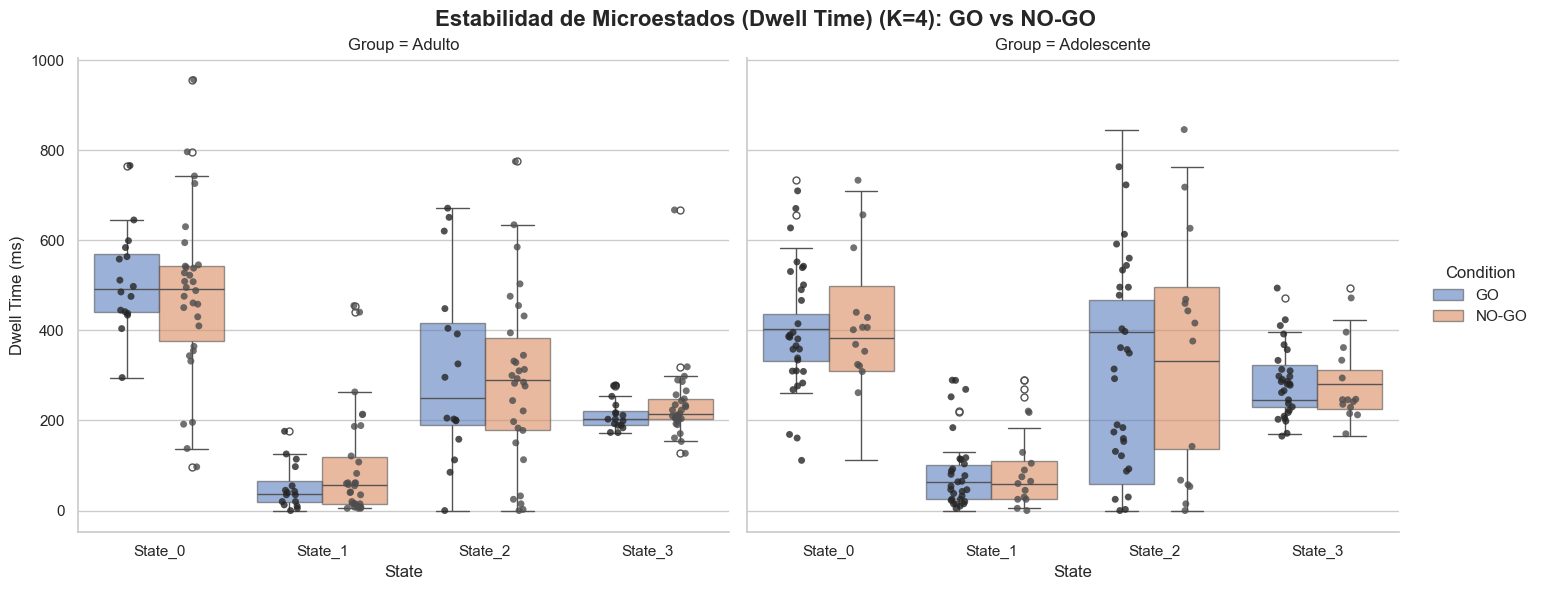

In [20]:
# CELDA 4: ESTABILIDAD (DWELL TIME)
# 1. Asegurarnos de aislar EXCLUSIVAMENTE las columnas de Dwell
columnas_dwell = [f'Dwell_State_{s}' for s in range(n_states)]

df_melted_dwell = df_subjects.melt(
    id_vars=['Subject', 'Group', 'Condition'], 
    value_vars=columnas_dwell, # <--- 100% dinámico
    var_name='State', 
    value_name='Dwell Time (ms)'
)

# Limpiar texto para la gráfica
df_melted_dwell['State'] = df_melted_dwell['State'].str.replace('Dwell_', '')

# 2. GRAFICAR DWELL TIME
g_dwell = sns.catplot(
    data=df_melted_dwell, 
    x='State', 
    y='Dwell Time (ms)', 
    hue='Condition', 
    col='Group', 
    kind='box', 
    height=6, 
    aspect=1.2,
    boxprops={'alpha': 0.6}
)
g_dwell.map_dataframe(sns.stripplot, x='State', y='Dwell Time (ms)', hue='Condition', dodge=True, alpha=0.8, palette='dark:.3')

g_dwell.fig.subplots_adjust(top=0.9)
# FIX: Título dinámico para saber qué versión de K estamos viendo
g_dwell.fig.suptitle(f"Estabilidad de Microestados (Dwell Time) (K={n_states}): GO vs NO-GO", fontsize=16, fontweight='bold')
plt.show()

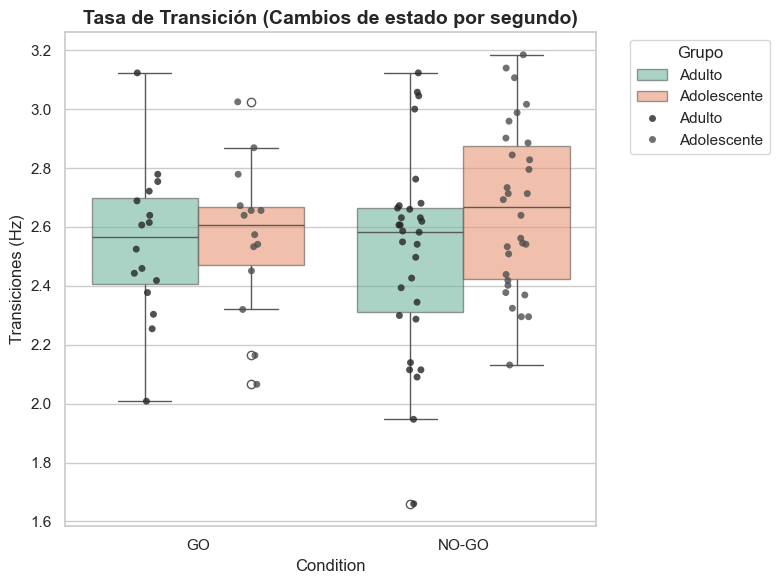

In [21]:
# CELDA 5: FLEXIBILIDAD VS CAOS (TRANSITION RATE)
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_subjects, 
    x='Condition', 
    y='Transition_Rate_Hz', 
    hue='Group',
    palette='Set2',
    boxprops={'alpha': 0.6}
)
sns.stripplot(
    data=df_subjects, 
    x='Condition', 
    y='Transition_Rate_Hz', 
    hue='Group',
    dodge=True,
    alpha=0.8,
    palette='dark:.3'
)
plt.title("Tasa de Transición (Cambios de estado por segundo)", fontsize=14, fontweight='bold')
plt.ylabel("Transiciones (Hz)")
plt.legend(title='Grupo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Cargando experimento: feat_task_k4_diag_pca90
Estados HMM: 4
Sujetos cargados: 118

Reconstruyendo épocas...
-> Tamaño de época detectado automáticamente: 61 ventanas
GO: 1179 épocas recuperadas
NOGO: 1180 épocas recuperadas
ADULTO_GO: 599 épocas recuperadas
ADULTO_NOGO: 600 épocas recuperadas
ADOLESCENTE_GO: 580 épocas recuperadas
ADOLESCENTE_NOGO: 580 épocas recuperadas

Épocas descartadas (anómalas): 0


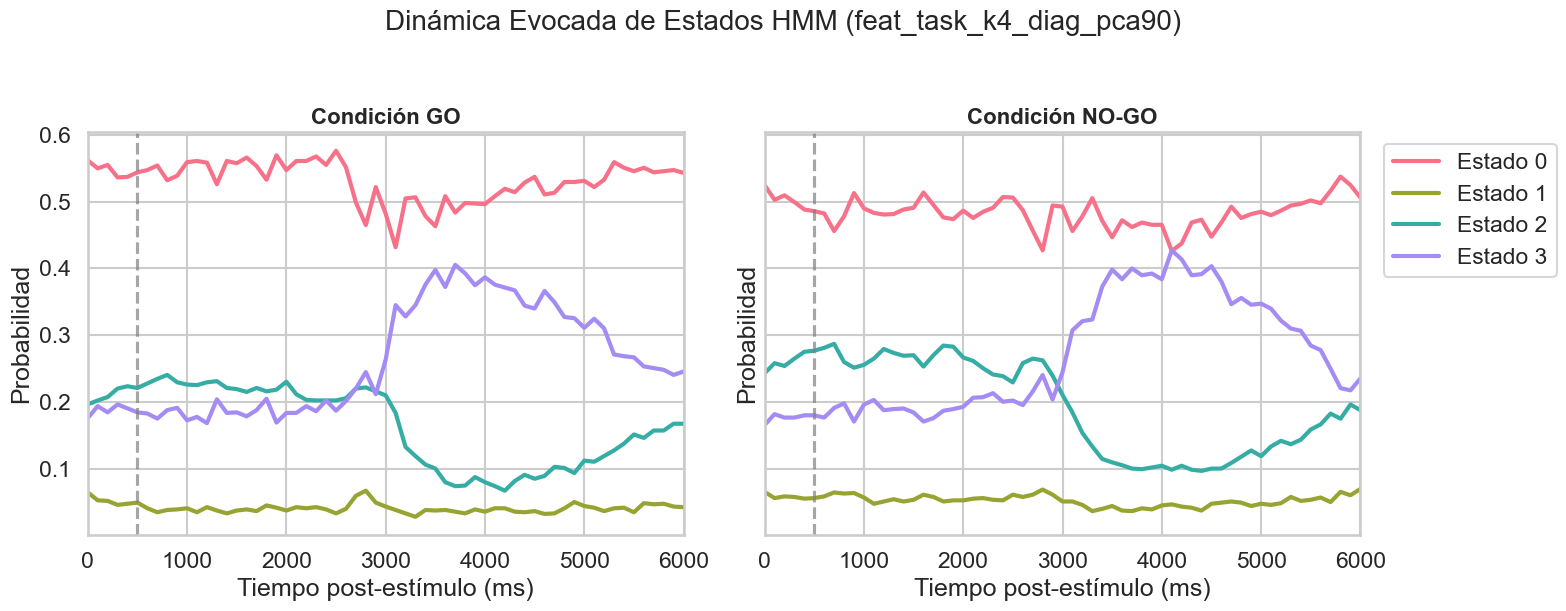

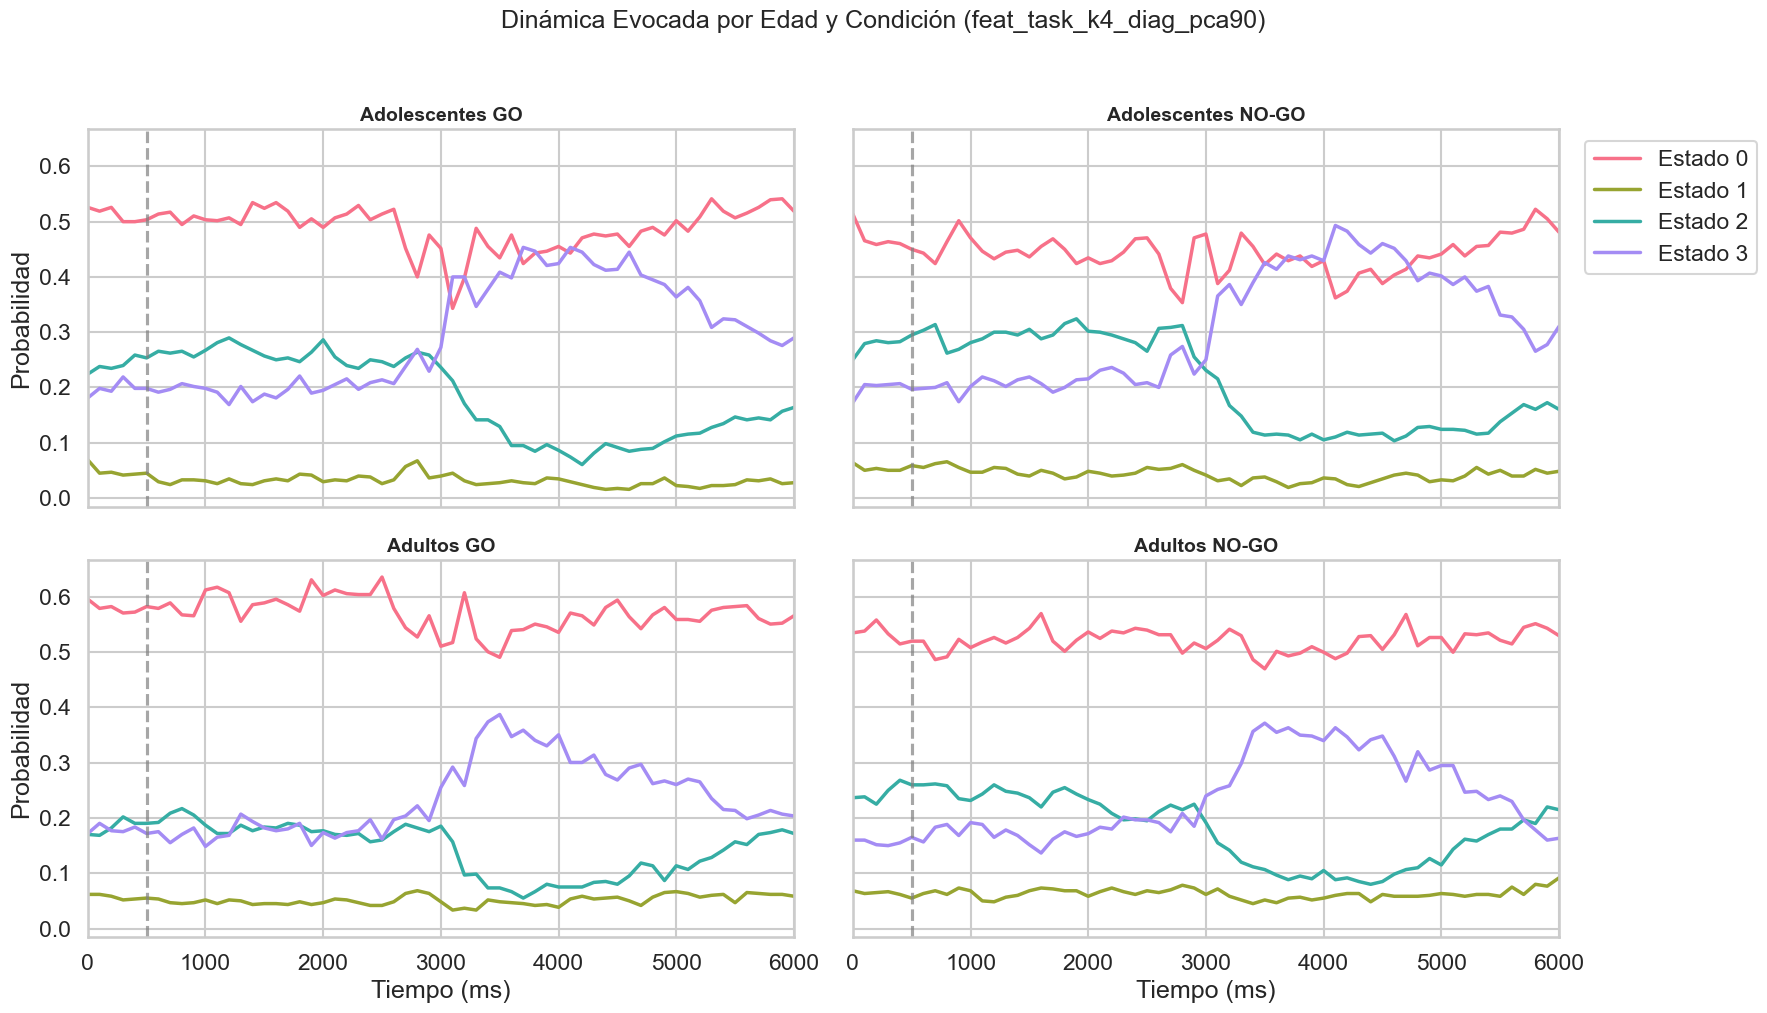


PROBABILIDAD EVOCADA MÁXIMA


,Group,State,Peak Time (ms),Peak Probability
0,GO,0,2500,0.575912
1,GO,1,2800,0.067854
2,GO,2,800,0.240882
3,GO,3,3700,0.405428
4,NOGO,0,5800,0.537288
5,NOGO,1,6000,0.070339
6,NOGO,2,700,0.287288
7,NOGO,3,4100,0.427119
8,ADULTO_GO,0,2500,0.636060
9,ADULTO_GO,1,2800,0.068447


In [1]:
# ============================================================
# EVOKED STATE DYNAMICS (GO vs NO-GO)
# Bugfix: Extracción de metadatos segura
# ============================================================

import os
import glob
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ============================================================
# CONFIG
# ============================================================

CONFIG_PATH = "../../configs/experiments/feat_task_k4_diag_pca90.yaml"

STEP_SIZE_MS = 100 

LISTA_ADULTOS = [
    'AAELSC', 'AAGFSC', 'EDGSSIN', 'FIJRBSIN', 'GSASC', 'IJALSC',
    'JAGSSC', 'LHACSIN', 'MAEGLSC', 'MAHLSC', 'MFGSIN', 'MGOKSC',
    'RAMPSIN', 'SDBGSIN', 'VMRSIN', 'AVLLSC', 'BMPSC', 'CGMSIN',
    'CJGSIN', 'CPGSC', 'CPMHSIN', 'GGMSIN', 'IABWSC', 'JAUSIN',
    'JGCSC', 'MGVGSC', 'RKACSC', 'SEOOSIN', 'TTOSC', 'VBPSIN'
]

# ============================================================
# LOAD EXPERIMENT
# ============================================================

with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

exp_name = cfg['experiment']['name']
k = cfg['pipeline']['hmm']['k_states']

exp_dir = os.path.join(
    "../../outputs/processed/experiments/feature_hmm/task/",
    exp_name
)

features_dir = "../../data/interim/features/task/"

print(f"Cargando experimento: {exp_name}")

viterbi = np.load(
    os.path.join(exp_dir, 'viterbi_paths_k4.npy')
)

length_files = sorted(
    glob.glob(os.path.join(features_dir, '*_lengths.npy'))
)

print(f"Estados HMM: {k}")
print(f"Sujetos cargados: {len(length_files)}")


# ============================================================
# HELPERS
# ============================================================

def parse_subject_info(filename):
    """
    Extracción quirúrgica: Limpia los sufijos de los archivos .npy para 
    evaluar si el nombre base termina en NOGO, NG o GO.
    """
    # 1. Limpieza implacable de TODO lo que no sea el ID
    clean_name = filename.upper()
    clean_name = clean_name.replace('_SIN_CONTEXTO', '')
    clean_name = clean_name.replace('_EPO', '')
    clean_name = clean_name.replace('_LENGTHS.NPY', '')
    clean_name = clean_name.replace('.NPY', '')
    
    # Ahora clean_name es puramente "AAELSCNOGO" o "AAELSC_NG" o "AAELSCGO"
    if clean_name.endswith("NOGO"):
        condicion = "NOGO"
        subject_id_real = clean_name[:-4] 
    elif clean_name.endswith("NG"):
        condicion = "NOGO"
        subject_id_real = clean_name[:-2] 
    elif clean_name.endswith("GO"):
        condicion = "GO"
        subject_id_real = clean_name[:-2] 
    else:
        # Resguardo de seguridad
        condicion = "GO"
        subject_id_real = clean_name

    grupo = "ADOLESCENTE"
    for adulto in LISTA_ADULTOS:
        if subject_id_real.startswith(adulto):
            grupo = "ADULTO"
            break
            
    return subject_id_real, grupo, condicion


def calcular_probabilidades(matriz, n_states, windows_per_epoch):
    if len(matriz) == 0:
        return np.zeros((n_states, windows_per_epoch))
    probs = np.zeros((n_states, matriz.shape[1]))
    for s in range(n_states):
        probs[s] = np.mean(matriz == s, axis=0)
    return probs


# ============================================================
# RECONSTRUCCIÓN DE SECUENCIAS
# ============================================================

print("\nReconstruyendo épocas...")

secuencias_crudas = {
    "GO": [],
    "NOGO": [],
    "ADULTO_GO": [],
    "ADULTO_NOGO": [],
    "ADOLESCENTE_GO": [],
    "ADOLESCENTE_NOGO": []
}

start_idx = 0
todas_las_longitudes = []

for f_path in length_files:
    filename = os.path.basename(f_path)
    subject_id_real, grupo, condicion = parse_subject_info(filename)
    
    lengths = np.load(f_path)

    for ep_len in lengths:
        ep_path = viterbi[start_idx:start_idx + ep_len]
        start_idx += ep_len
        
        todas_las_longitudes.append(ep_len)

        secuencias_crudas[condicion].append(ep_path)
        secuencias_crudas[f"{grupo}_{condicion}"].append(ep_path)

# Detección automática del tamaño de época dominante
WINDOWS_PER_EPOCH = Counter(todas_las_longitudes).most_common(1)[0][0]
print(f"-> Tamaño de época detectado automáticamente: {WINDOWS_PER_EPOCH} ventanas")

# Filtrar solo las épocas válidas
matrices = {}
epocas_ignoradas = 0

for key, lista_epocas in secuencias_crudas.items():
    epocas_validas = [ep for ep in lista_epocas if len(ep) == WINDOWS_PER_EPOCH]
    matrices[key] = np.array(epocas_validas)
    
    # Calcular las ignoradas solo para los conjuntos generales ("GO", "NOGO")
    if key in ["GO", "NOGO"]:
        epocas_ignoradas += (len(lista_epocas) - len(epocas_validas))
        
    print(f"{key}: {len(epocas_validas)} épocas recuperadas")

print(f"\nÉpocas descartadas (anómalas): {epocas_ignoradas}")


# ============================================================
# CALCULAR PROBABILIDADES EVOCADAS
# ============================================================

time_axis = np.arange(WINDOWS_PER_EPOCH) * STEP_SIZE_MS

probs = {
    key: calcular_probabilidades(value, k, WINDOWS_PER_EPOCH)
    for key, value in matrices.items()
}


# ============================================================
# PLOT 1 — GO vs NOGO
# ============================================================

sns.set_theme(style="whitegrid", context="talk")
colors = sns.color_palette("husl", k)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True, sharex=True)

paneles = [
    ("GO", "Condición GO"),
    ("NOGO", "Condición NO-GO")
]

for ax, (key, title) in zip(axes, paneles):
    matriz = probs[key]
    for s in range(k):
        ax.plot(
            time_axis,
            matriz[s],
            lw=3,
            label=f"Estado {s}",
            color=colors[s]
        )
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel("Tiempo post-estímulo (ms)")
    ax.set_ylabel("Probabilidad")
    
    # Asumiendo baseline de 500ms
    ax.axvline(x=500, linestyle='--', alpha=0.7, color='gray') 
    ax.set_xlim(0, max(time_axis))

axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.suptitle(f"Dinámica Evocada de Estados HMM ({exp_name})", fontsize=20, y=1.03)
plt.tight_layout()
plt.show()


# ============================================================
# PLOT 2 — MATRIZ 2x2 DESARROLLO
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True, sharey=True)

config_panels = [
    (0, 0, "ADOLESCENTE_GO", "Adolescentes GO"),
    (0, 1, "ADOLESCENTE_NOGO", "Adolescentes NO-GO"),
    (1, 0, "ADULTO_GO", "Adultos GO"),
    (1, 1, "ADULTO_NOGO", "Adultos NO-GO")
]

for row, col, key, title in config_panels:
    ax = axes[row, col]
    matriz = probs[key]
    for s in range(k):
        ax.plot(
            time_axis,
            matriz[s],
            lw=2.5,
            label=f"Estado {s}",
            color=colors[s]
        )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axvline(x=500, linestyle='--', alpha=0.7, color='gray') 
    
    if row == 1: ax.set_xlabel("Tiempo (ms)")
    if col == 0: ax.set_ylabel("Probabilidad")
    ax.set_xlim(0, max(time_axis))

axes[0,1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.suptitle(f"Dinámica Evocada por Edad y Condición ({exp_name})", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# MÉTRICAS TEMPORALES RESUMEN
# ============================================================

print("\n================================================")
print("PROBABILIDAD EVOCADA MÁXIMA")
print("================================================")

summary = []
for group_name, matrix in probs.items():
    if len(matrix[0]) == 0: continue # Omitir si está vacío
    for s in range(k):
        peak_idx = np.argmax(matrix[s])
        peak_time = time_axis[peak_idx]
        peak_prob = matrix[s, peak_idx]
        summary.append({
            'Group': group_name,
            'State': s,
            'Peak Time (ms)': peak_time,
            'Peak Probability': peak_prob
        })

display(pd.DataFrame(summary))